In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# 1. Load and Merge (Same as before)
gold = pd.read_csv('Gold Price.csv').sort_values('Date')
gold['Date'] = pd.to_datetime(gold['Date'])
usd = pd.read_csv('USD_INR Historical Data (1).csv').sort_values('Date')
usd['Date'] = pd.to_datetime(usd['Date'], dayfirst=True)
cpi = pd.read_csv('CPIndex_Jan15-To-Jan25.csv', skiprows=1)
cpi['Date'] = pd.to_datetime(cpi['Year'].astype(str) + '-' + cpi['Month'], format='%Y-%B')

df = pd.merge(gold[['Date', 'Price']], usd[['Date', 'Price']], on='Date', how='inner', suffixes=('_Gold', '_USD'))
cpi_daily = pd.merge(pd.DataFrame({'Date': pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')}),
                     cpi[['Date', 'Combined Inflation']], on='Date', how='left').ffill()
df = pd.merge(df, cpi_daily, on='Date', how='inner').dropna()

# 2. THE FIX: Calculate Daily Percentage Returns
df['Gold_Return'] = df['Price_Gold'].pct_change()
df['Gold_Lag_Price'] = df['Price_Gold'].shift(1)
df['USD_Lag_Price'] = df['Price_USD'].shift(1)
df['SMA_7'] = df['Price_Gold'].rolling(7).mean()
df = df.dropna()

# 3. Train on Returns
features = ['Gold_Lag_Price', 'USD_Lag_Price', 'SMA_7', 'Combined Inflation']
X = df[features]
y = df['Gold_Return'] # We are predicting the % CHANGE now
model_ret = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)

print("✅ Advanced Return-based Model trained!")

✅ Advanced Return-based Model trained!


In [ ]:
#@title 🎯 Enter Your Prediction Date
target_date_input = "2026-02-01" #@param {type:"string"}
target_date = pd.to_datetime(target_date_input)

def get_dynamic_forecast(target_date):
    last_row = df.iloc[-1]
    current_date = last_row['Date']

    # Starting values
    curr_gold = last_row['Price_Gold']
    curr_usd = last_row['Price_USD']
    curr_cpi = last_row['Combined Inflation']

    # We keep a list of recent prices to update the SMA_7 dynamically
    recent_prices = df['Price_Gold'].iloc[-7:].tolist()

    if target_date <= current_date:
        return f"Historical Price for {target_date.date()}: {df[df['Date'] <= target_date].iloc[-1]['Price_Gold']:.2f} INR"

    days_to_go = (target_date - current_date).days

    # Forecast Loop
    for _ in range(days_to_go):
        curr_sma7 = np.mean(recent_prices)

        # Prepare input
        input_data = pd.DataFrame([[curr_gold, curr_usd, curr_sma7, curr_cpi]], columns=features)

        # Predict the percentage change for the next day
        pred_return = model_ret.predict(input_data)[0]

        # Calculate the new price
        next_gold = curr_gold * (1 + pred_return)

        # Update values for the next day in the loop
        curr_gold = next_gold
        recent_prices.append(next_gold)
        recent_prices.pop(0) # Keep SMA window at 7

    return f"🚀 Predicted Dynamic Gold Price for {target_date.date()}: {curr_gold:.2f} INR"

print(get_dynamic_forecast(target_date))

🚀 Predicted Dynamic Gold Price for 2026-02-01: 189059.24 INR


--- NEW RETURN-BASED MODEL ACCURACY ---
Accuracy: 99.76%
R2 Score: 0.9996
Average Error (MAE): 191.45 INR
---------------------------------------


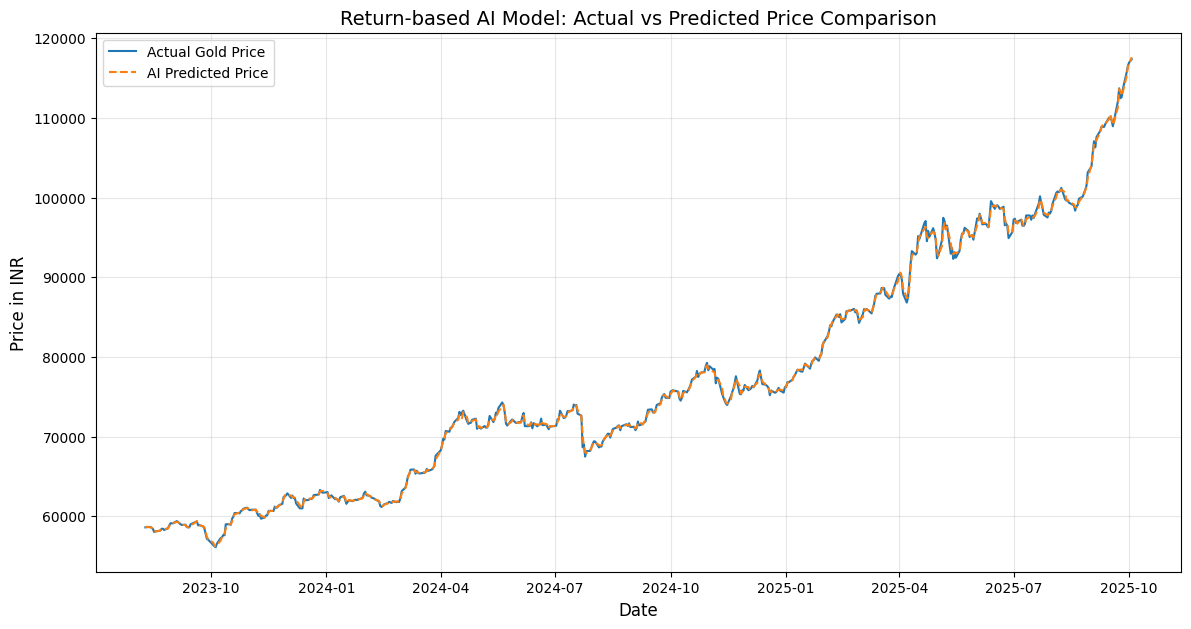

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Prepare Test Data
# Rename columns in test_df to match the feature names used during model training
X_test = test_df.rename(columns={'Gold_Lag': 'Gold_Lag_Price', 'USD_Lag': 'USD_Lag_Price'})[features]
actual_prices = test_df['Price_Gold'].values
yesterday_prices = test_df['Gold_Lag'].values # This uses the original Gold_Lag for the price calculation

# 2. Predict Returns and Convert to Absolute Prices
# Formula: Today's Predicted Price = Yesterday's Price * (1 + Predicted % Change)
pred_returns = model_ret.predict(X_test)
predicted_prices = yesterday_prices * (1 + pred_returns)

# 3. Calculate Metrics
mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
r2 = r2_score(actual_prices, predicted_prices)
mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
accuracy = 100 - mape

print("--- NEW RETURN-BASED MODEL ACCURACY ---")
print(f"Accuracy: {accuracy:.2f}%")
print(f"R2 Score: {r2:.4f}")
print(f"Average Error (MAE): {mae:.2f} INR")
print("---------------------------------------")

# 4. Plotting the Comparison
plt.figure(figsize=(14, 7))
plt.plot(test_df['Date'], actual_prices, label='Actual Gold Price', color='#1f77b4', linewidth=1.5)
plt.plot(test_df['Date'], predicted_prices, label='AI Predicted Price', color='#ff7f0e', linestyle='--', linewidth=1.5)

plt.title('Return-based AI Model: Actual vs Predicted Price Comparison', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price in INR', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()